Enter how many elements: 19
Enter the number of nodes: 11
Enter the number nodes that are constrained: 2
Enter coordinates for node 1 (x y) in m: 0 0 
Enter coordinates for node 2 (x y) in m: 1 3
Enter coordinates for node 3 (x y) in m: 2 6
Enter coordinates for node 4 (x y) in m: 3 9
Enter coordinates for node 5 (x y) in m: 7 9
Enter coordinates for node 6 (x y) in m: 8 6
Enter coordinates for node 7 (x y) in m: 9 3
Enter coordinates for node 8 (x y) in m: 10 0
Enter coordinates for node 9 (x y) in m: 5 6
Enter coordinates for node 10 (x y) in m: 5 3
Enter coordinates for node 11 (x y) in m: 5 0
Enter the node numbers for element 1 (start end): 1 11
Enter the node numbers for element 2 (start end): 11 8
Enter the node numbers for element 3 (start end): 2 10
Enter the node numbers for element 4 (start end): 10 7
Enter the node numbers for element 5 (start end): 3 9
Enter the node numbers for element 6 (start end): 9 6
Enter the node numbers for element 7 (start end): 4 5
Enter the node

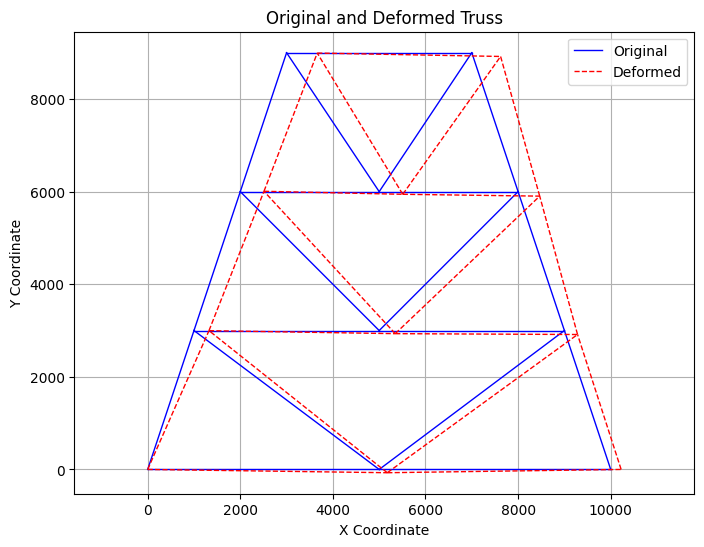

In [ ]:
#########  SOLVING A 2-D TRUSS USING FEM  #########

import numpy as np
import sympy as sp
import matplotlib.pyplot as plt

# Geometric inputs
elements = int(input("Enter how many elements: ")) # Number of Elements
nodes = int(input("Enter the number of nodes: ")) # Number of Nodes
constraints = int(input("Enter the number of nodes that are constrained: "))
force = nodes - constraints
A = 100.0 # Area (mm2)
E = 200000.0 # Modulus of Elasticity (MPa)

# Initialize arrays
node_coordinates = np.zeros((nodes, 2))  # 2D coordinates (x, y)
element_connectivity = np.zeros((elements, 2), dtype=int)
constraints_x_y = np.zeros((constraints, 3))
external_forces = np.zeros((force, 3))
element_orientation = np.zeros(elements)
element_length = np.zeros(elements)
element_stiffness_matrices = []
element_direction = np.zeros((elements, 4))
global_stiffness_matrix = np.zeros((2*nodes, 2*nodes))

# Define symbols for displacements and forces
u_vars = sp.symbols(f'u1:{(2*nodes)+1}')
node_displacements = sp.Matrix(u_vars)
f_vars = sp.symbols(f'f1:{(2*nodes)+1}')
node_forces = sp.Matrix(f_vars)

# Loop to get coordinates for each node
for i in range(nodes):
  coord_input = input(f"Enter coordinates for node {i+1} (x y) in m: ").split()
  x = float(coord_input[0]) * 1000.0
  y = float(coord_input[1]) * 1000.0
  node_coordinates[i] = [x, y]

# Loop to get the node connectivity for each element
for i in range(elements):
  n1, n2 = map(int, input(f"Enter the node numbers for element {i+1} (start end): ").split())
  element_connectivity[i] = [n1, n2]

# Loop to get Boundary Conditions
for i in range(constraints):
  node, x, y = map(float, input(f"(n=node number, x,y=0 if no constraint, 1 if there is constraint (n x y)): ").split())
  constraints_x_y[i] = [node, x, y]

# Loop to get element directions
dof = np.arange(1, 2*nodes+1)
directions = dof.reshape(-1, 2)
for i in range(elements):
  n1, n2 = element_connectivity[i]
  a, b = directions[n1-1]
  c, d = directions[n2-1]
  element_direction[i] = [a-1, b-1, c-1, d-1]

# Apply the constraints to the node_displacements matrix
for i in range(constraints):
  node, x_constraint, y_constraint = constraints_x_y[i]
  if x_constraint == 1:
    node_displacements[2*int(node)-2] = 0
  if y_constraint == 1:
    node_displacements[2*int(node)-1] = 0
  if x_constraint == 0:
    node_forces[2*int(node)-2] = 0
  if y_constraint == 0:
    node_forces[2*int(node)-1] = 0

# Loop to get External Forces
for i in range(force):
  node_input = input(f"(n=node number, fx, fy = 0 if no force, magnitude (in kN) if there is force (n fx fy)): ").split()
  node = int(node_input[0])  # Ensure node is an integer
  fx = float(node_input[1]) * 1000.0  # Convert force to Newtons
  fy = float(node_input[2]) * 1000.0
  external_forces[i] = [node, fx, fy]

########## END OF INPUTS ##########

# Apply Force values to node forces matrix
for i in range(force):
  node, fx, fy = external_forces[i]
  node_forces[2*int(node)-2] = fx
  node_forces[2*int(node)-1] = fy

# Loop to calculate length, orientation and stiffness of each element
for i in range(elements):
  # Extracting Coordinates
  n1, n2 = element_connectivity[i]
  x1, y1 = node_coordinates[n1-1]
  x2, y2 = node_coordinates[n2-1]

  # Finding Length and Orientation
  L = round(np.sqrt((x2 - x1)**2 + (y2 - y1)**2), 2)
  theta = np.arctan2(y2 - y1, x2 - x1)
  element_length[i] = L
  element_orientation[i] = theta

  # Compute direction cosines
  c = round(np.cos(theta), 3)
  s = round(np.sin(theta), 3)

  # Compute element stiffness matrix
  k = (E * A / L) * np.array([
      [ c**2,  c*s, -c**2, -c*s],
      [ c*s,  s**2, -c*s, -s**2],
      [-c**2, -c*s,  c**2,  c*s],
      [-c*s, -s**2,  c*s,  s**2]
    ])

  # Store the stiffness matrix
  element_stiffness_matrices.append(k)

# Generating Global Stiffness Matrix
for i in range(elements):
  indices = element_direction[i]
  for j in range(4):
    for k in range(4):
        global_stiffness_matrix[int(indices[j]), int(indices[k])] += round(element_stiffness_matrices[i][j, k], 3)

# Printing Element Stiffness Matrix of Each Element
print("Element Stiffness Matrices:")
for i, k in enumerate(element_stiffness_matrices):
  print(f"Element {i+1}:")
  print(k)

# Printing U, F and K Matrices
print("Node Displacements:")
print(node_displacements)
print("Node Forces:")
print(node_forces)
print("Global Stiffness Matrix:")
print(global_stiffness_matrix)

# Seggregating known and unknown dofs
constrained_dofs = []
free_dofs = []
for i in range(2 * nodes):
  if node_displacements[i] == 0:  # Constrained DOFs (from BCs)
    constrained_dofs.append(i)
  else:
    free_dofs.append(i)  # Unconstrained DOFs (Unknown Displacements)

# Extracting Sub Matrix for free DOFs of Force
F_known = []
for i in free_dofs:
  F_known.append(node_forces[i])

# Converting K and F to Symbolic Matrix
K = sp.Matrix(global_stiffness_matrix)
F_known = sp.Matrix(F_known)

# Extracting Sub Matrix for free DOFs of Stiffness
K_free = K.extract(free_dofs, free_dofs)

# Solve for unknown displacements
solution = sp.linsolve([K_free, F_known], *[u_vars[i] for i in free_dofs])

# Convert solution to dictionary for substitution
solution_dict = {}
if solution:
  displacement_values = solution.args[0]  # Extract solution tuple
  for idx, val in enumerate(displacement_values):
    solution_dict[u_vars[free_dofs[idx]]] = val

# Fill in the full displacement vector
full_displacement = node_displacements.copy()
for dof in free_dofs:
  full_displacement[dof] = solution_dict[u_vars[dof]]
full_displacement = full_displacement.applyfunc(lambda x: x.evalf(6))

print("\nFull Displacement Matrix:")
print(full_displacement)

# Calculate the full force vector using F = K * U
F_calculated = K * full_displacement
F_calculated = F_calculated.applyfunc(lambda x: x.evalf(6))

print("\nFull Force Vector:")
print(F_calculated)

# Calculating Member Forces
member_forces = []

for i in range(elements):
  indices = element_direction[i].astype(int)
  u_e = sp.Matrix([full_displacement[idx] for idx in indices])  # Extract element displacements
  alpha = element_orientation[i]

  # Compute direction cosines
  c = round(np.cos(alpha), 3)
  s = round(np.sin(alpha), 3)

  # Converting from Global to Local Coordinates
  len = element_length[i]
  transform = (E * A / len) * np.array([
      [c, s, 0, 0],
      [-s, c, 0, 0],
      [0, 0, c, s],
      [0, 0, -s, c]
    ])

  u_e_bar = transform * u_e
  Q_e_bar = (u_e_bar[2] - u_e_bar[0])
  member_forces.append(Q_e_bar)

# Print member forces
print("\nMember Forces (C -,  T +):")
print(member_forces)

# Compute deformed coordinates
deformed_coordinates = node_coordinates.copy()
for i in range(nodes):
    deformed_coordinates[i, 0] += float(full_displacement[2 * i])
    deformed_coordinates[i, 1] += float(full_displacement[2 * i + 1])

# Create the figure
plt.figure(figsize=(8, 6))

# Plot the original truss
for i in range(elements):
    n1, n2 = element_connectivity[i]
    x_values = [node_coordinates[n1 - 1, 0], node_coordinates[n2 - 1, 0]]
    y_values = [node_coordinates[n1 - 1, 1], node_coordinates[n2 - 1, 1]]
    plt.plot(x_values, y_values, 'b-', linewidth=1, label="Original" if i == 0 else "")

# Plot the deformed truss
for i in range(elements):
    n1, n2 = element_connectivity[i]
    x_values = [deformed_coordinates[n1 - 1, 0], deformed_coordinates[n2 - 1, 0]]
    y_values = [deformed_coordinates[n1 - 1, 1], deformed_coordinates[n2 - 1, 1]]
    plt.plot(x_values, y_values, 'r--', linewidth=1, label="Deformed" if i == 0 else "")

# Labels, legend, and dynamic limits
plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.title('Original and Deformed Truss')
plt.legend()
plt.grid(True)
plt.axis('equal')

# Show the plot
plt.show()
